<font size="6">Housing price prediction example using Linear Regression</font>

This example provides Closed Form solution and Ordinary Least Squares solution of Linear Regression.

In [1]:
import numpy as np # ---> Numpy library for array manipulation
import pandas as pd # ---> Pandas library for data manipulation
import matplotlib.pyplot as plt # ---> library for data visualization

In [3]:
#Generate a random data
# to initialize the pseudo-random number generator, ensuring that a specific sequence of "random" 
# numbers can be reproduced. seed value is the starting point of this 
np.random.seed(0)
# np.random.randn a function in the NumPy library for Python that generates random numbers from the standard
# normal distribution. This is also known as the Gaussian distribution with a mean of 0 and a variance of 1 
# (and thus, a standard deviation of 1).
# Returns array of defined shape with floating point samples from standard normal distribution
# here it generates a 1-D array with 100 values
area = 2.5 * np.random.randn(100) + 25
# randint for random integers, here a 1-D array with size same as area array and values in between 20 and 50
# low = 20, high = 50
price = 25 * area + 5 + np.random.randint(20,50, size = len(area))
data = np.array([area, price]) # creates a 2-D array
# A pandas DataFrame is a two-dimensional, mutable, tabular data structure with labeled axes (rows and columns). 
# A DataFrame can be created from sources like dictionaries, Numpy arrays, CSV files, Excel sheets, SQL database
data = pd.DataFrame(data = data.T, columns=['area','price'])
#display top 5 entries
data.head(5)

,area,price
0,29.410131,760.253272
1,26.000393,679.009826
2,27.446845,738.171124
3,30.602233,817.055825
4,29.668895,791.722374


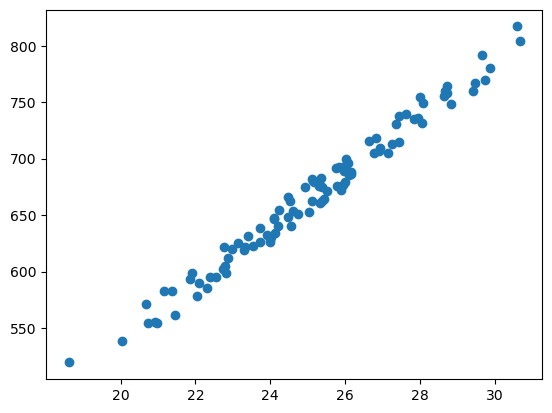

In [4]:
# function creates scatter plots, which are used to visualize the relationship between two numerical variables.
plt.scatter(data['area'], data['price'])
plt.show()

This is a typical bivariate linear regression problem. 
Bivariate linear regression models the relationship between a single independent variable
𝑥 (area) and a dependent variable 𝑦 (price) by fitting a straight line to observed data. In its parameterized form using weight 𝑊 and bias 𝑏 the model is written as 𝑦' = 𝑊𝑥 + 𝑏 where 𝑦' is the predicted output, 𝑊 represents the slope (the rate of change of 𝑦 with respect to 𝑥) and 𝑏 is the intercept (the value of 𝑦 when 𝑥 = 0).

For estimating weight 𝑊 and bias 𝑏, use closed form solution.The closed-form solution of linear regression means we can calculate the best values of the model parameters directly using a mathematical formula, instead of finding them step-by-step through an iterative method like gradient descent.
In simple terms, imagine you want to draw the best straight line through a set of data points. That line is written as:
 𝑦' = 𝑊𝑥 + 𝑏.The goal is to choose values of 𝑊 and 𝑏 that make the line fit the data as closely as possible. “Closely” is usually measured using Mean Squared Error (MSE) — the average of the squared differences between actual values 𝑦 and predicted values 𝑦'
The closed-form solution gives exact formulas for 𝑊 and 𝑏 that minimize this error:

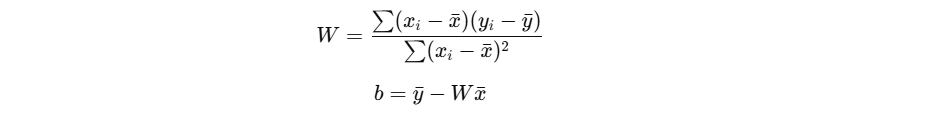

So instead of adjusting 𝑊 and 𝑏 repeatedly (like gradient descent does), we plug the data directly into these formulas and get the optimal values in one step.
 

In [10]:
W = sum((area - np.mean(area))*(price - np.mean(price))) / sum((area-np.mean(area))**2)
b = np.mean(price) - W*np.mean(area)
print("The regression coefficients are", W,b)

The regression coefficients are 24.815544052285617 43.4989785533254


In [6]:
y_pred = W * area + b

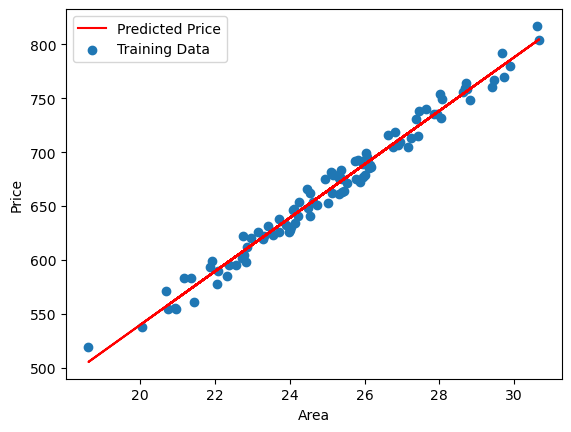

In [11]:
plt.plot(area, y_pred, color='red',label="Predicted Price")
plt.scatter(data['area'], data['price'], label="Training Data")
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()

Closed form solution of linear regression is suitable for small datasets. It requires the entire dataset to be in memory at once, which can be problematic for very large datasets. sklearn.linear_model.LinearRegression uses robust, high-performance numerical linear algebra libraries to iteratively or directly approximate the solution. Generally more efficient for larger datasets and features by using optimized algorithms designed for scale.The underlying solvers are optimized and can handle large data more gracefully, and related sklearn models (like SGDRegressor) can even use mini-batches for data that won't fit in memory. Here we use Ordinary Least Squares Linear Regression model from sklearn library. Ordinary Least Squares method provides the best fit model, minimiz

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(data[['area']],data[['price']])


LinearRegression()

In [18]:
model.coef_

array([[24.81554405]])

In [19]:
model.intercept_

array([43.49897855])

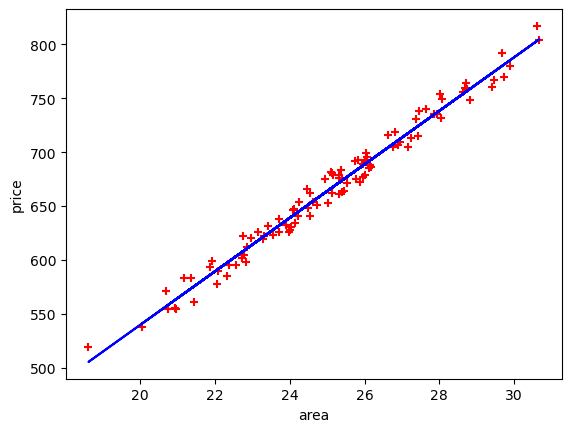

In [16]:
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(data.area, data.price, color='red',marker='+')
plt.plot(data.area, model.predict(data[['area']]),color = 'blue')